In [ ]:
from pyspoc import Calculator, Config
from pathlib import Path
import os
import numpy as np
import pandas as pd
# Add the parent of the current script's parent to sys.path
project_root = Path('./').resolve().parents[1]

In [ ]:
# my_config_yaml = f"{project_root}/notebooks/testing_summary_stats/cov_reducer_yaml.yml"

my_config_yaml = f"{project_root}/notebooks/testing_summary_stats/cov_reducer_yaml.yml"

my_config_name = "new_config"
cfg = Config.from_yaml_file(my_config_name, my_config_yaml)

In [3]:
# key = main folder, value = sub folder, None if no need

data_files_dict = {}

data_files_dict['spherical_gaussian_cloud'] = None

data_files_dict['sphericalGaussian_homoskedastic_blobs'] = 'k3_std1.0'

data_files_dict['ellipsoidal_gaussian_cloud'] = None

data_files_dict['ellipsoidGaussian_homoskedastic_blobs'] = 'k3_std1.0'

data_files_dict['lmm_torusEmbedded_3D'] = 'lenscale1.0_noise0.1_torus1'

## PARSE THE ISO AND ANISO GAUSSIAN FOLDERS

filename_dict = {}

for dataset_type in data_files_dict.keys():

    n_sample = 1000
    n_feature = 100
    base_dir = os.path.join(project_root,'data','synthetic_data',dataset_type,f'N{n_sample}_P{n_feature}')

    if data_files_dict[dataset_type] is None:
        subfolder_path = base_dir
    else:
        subfolder_path = os.path.join(base_dir,data_files_dict[dataset_type])        

    meta_file = os.path.join(subfolder_path, "meta.csv")
    meta_df = pd.read_csv(meta_file)

    ## change this to take sample_num from meta_df:
    filename_dict[dataset_type] = {v.split('_')[0] : os.path.join(subfolder_path,v) for v in meta_df['filename']}

In [4]:
flat = {f"{k}_{sk}": sv for k, v in filename_dict.items() for sk, sv in v.items()}

In [ ]:
# len(flat.keys())

In [ ]:
# from scipy.stats import skew, kurtosis
# from scipy.spatial.distance import cdist,pdist
# dist_distr = pdist(sample_X, metric = 'euclidean')
# kurt = np.mean(dist_distr)
# type(kurt)

In [ ]:
res_dict = {}

for sample_file in flat.keys():

    print(sample_file)

    sample_X = np.load(flat[sample_file])

    calc = Calculator(sample_X)
    calc.compute(cfg)
    results = calc.results

    res_dict[sample_file] = results

    # break

In [6]:
print('done!')

done!


### visualize dataset embedding space

In [7]:
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA


In [8]:
concat_res = pd.concat(res_dict).reset_index()
concat_res['data_type'] = concat_res['level_0'].map(lambda v : '_'.join(v.split('_')[:-1]))
concat_res = concat_res.set_index([('level_0', ''),('level_1', ''),('data_type', '')])

pca = PCA(n_components=min(concat_res.shape[0],concat_res.shape[1]))
res_pca = pca.fit_transform(concat_res)
print(res_pca.shape)

(50, 5)


In [9]:
unique_dtypes = concat_res.T.columns.get_level_values(2).unique()
unique_dtype_dict = dict(zip(unique_dtypes,[i for i in range(len(unique_dtypes))]))
dtype_lst = [v for v in concat_res.T.columns.get_level_values(2)]

In [10]:
plot_df = pd.DataFrame({ 'pc0' : res_pca[:,0], 'pc1' : res_pca[:,1], 'dtype' : dtype_lst})

Text(0.5, 1.0, 'pca of dataset-embedding space, N = 1000, P = 100')

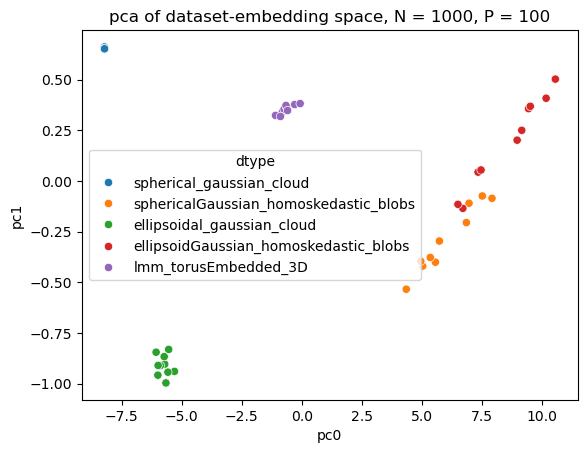

In [11]:
sns.scatterplot(plot_df,x='pc0', y = 'pc1', hue = 'dtype')
plt.title('pca of dataset-embedding space, N = 1000, P = 100')

In [12]:
summed_var = np.cumsum(pca.explained_variance_ratio_)

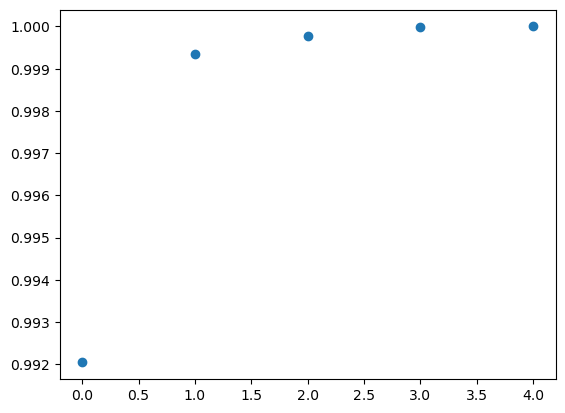

In [13]:
plt.scatter(y = summed_var, x = range(len(summed_var)))